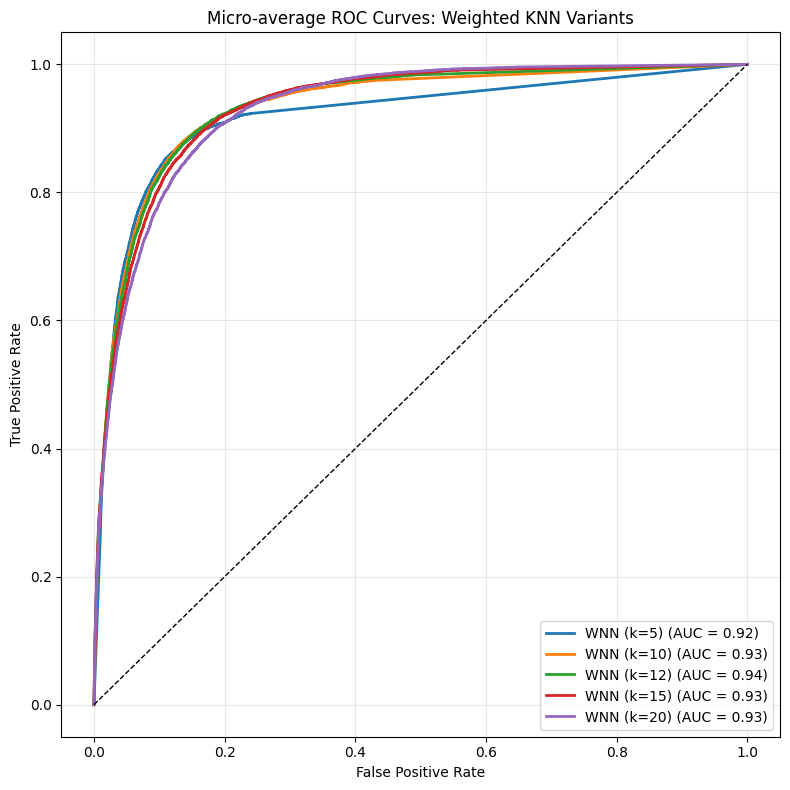

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier

def main():
    # 1) Load dataset (adjust path as needed)
    df = pd.read_csv('soil_csv_pre-processed.csv')

    # 3) Prepare features & target
    X = df.drop(columns=['Disease_Type'])
    y = df['Disease_Type']

    # One-hot encode categoricals
    X = pd.get_dummies(X, drop_first=True)

    # Binarize the multi-class target
    lb = LabelBinarizer()
    y_bin = lb.fit_transform(y)

    # 4) Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.3, stratify=y, random_state=42
    )

    # 5) Define five WNN variants with different k
    neighbor_settings = [5, 10, 12, 15, 20]
    models = [
        (f'WNN (k={k})', KNeighborsClassifier(n_neighbors=k, weights='distance'))
        for k in neighbor_settings
    ]

    # 6) Train each, get scores, compute micro-avg ROC & AUC
    plt.figure(figsize=(8, 8))
    for name, knn in models:
        ovr = OneVsRestClassifier(knn)
        ovr.fit(X_train, y_train)
        y_score = ovr.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    # 7) Plot chance line and finalize
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Micro-average ROC Curves: Weighted KNN Variants')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


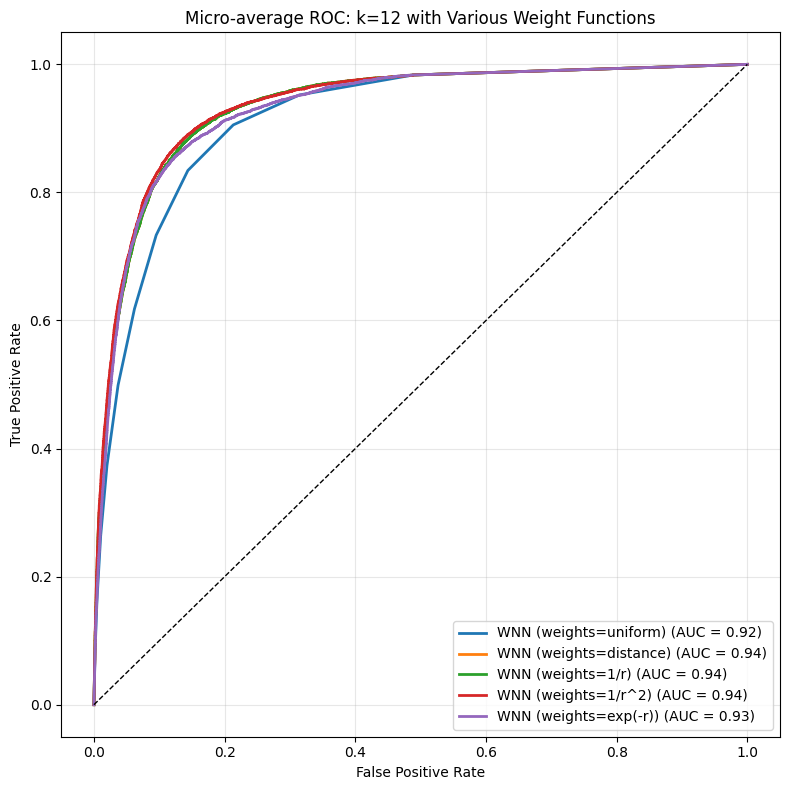

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier

def main():
    # 1) Load dataset (adjust path as needed)
    df = pd.read_csv('soil_csv_pre-processed.csv')

    # 3) Prepare features & target
    X = df.drop(columns=['Disease_Type'])
    y = df['Disease_Type']

    X = pd.get_dummies(X, drop_first=True)           # one-hot encode
    lb = LabelBinarizer()                            # binarize target
    y_bin = lb.fit_transform(y)

    # 4) Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.3, stratify=y, random_state=42
    )

    # 5) Define five WNN variants, all with k=12 but different weights
    def inv(d):     return 1.0 / (d + 1e-5)
    def inv_sq(d):  return 1.0 / (d**2 + 1e-5)
    def exp_dec(d): return np.exp(-d)

    weight_settings = [
        ('uniform',   'uniform'),
        ('distance',  'distance'),
        ('1/r',       inv),
        ('1/r^2',     inv_sq),
        ('exp(-r)',   exp_dec)
    ]

    models = [
        (f'WNN (weights={name})',
         KNeighborsClassifier(n_neighbors=12, weights=func))
        for name, func in weight_settings
    ]

    # 6) Train each, compute micro-avg ROC & AUC, plot on same figure
    plt.figure(figsize=(8,8))
    for label, knn in models:
        ovr = OneVsRestClassifier(knn)
        ovr.fit(X_train, y_train)
        y_score = ovr.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

    # 7) Add chance line & finalize
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Micro-average ROC: k=12 with Various Weight Functions')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()



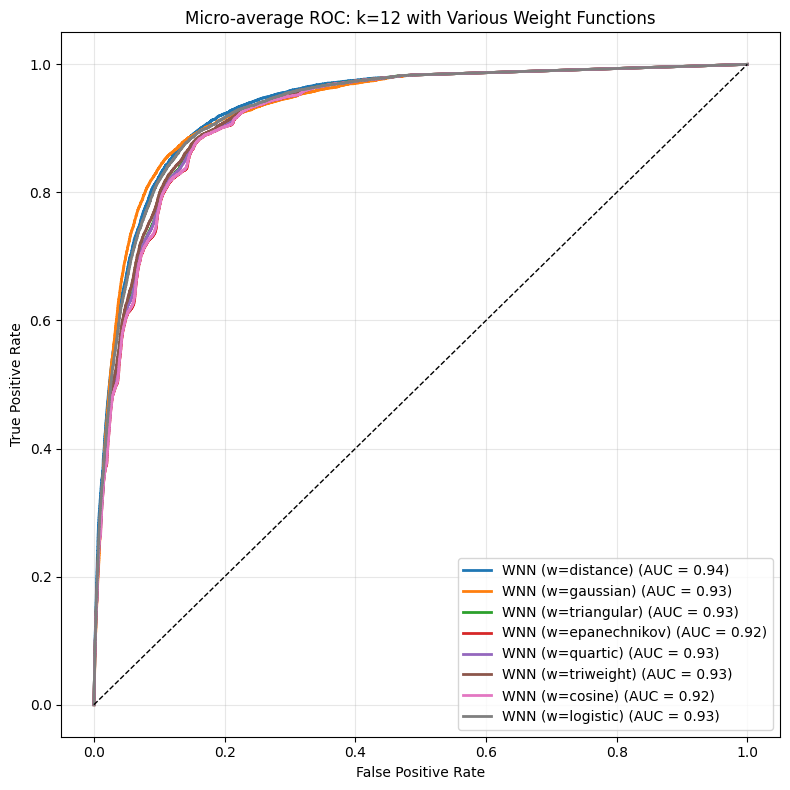

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier

def gaussian_weights(distances):
    # use std of distances as bandwidth σ (fallback to 1.0 if zero)
    sigma = np.std(distances) or 1.0
    return np.exp(-(distances**2) / (2 * sigma**2))

def triangular_weights(distances):
    h = distances.max()
    return np.maximum(1 - distances / h, 0)

def epanechnikov_weights(distances):
    h = distances.max()
    w = 1 - (distances**2) / (h**2)
    return np.where(distances <= h, 0.75 * w, 0)

def quartic_weights(distances):
    h = distances.max()
    w = 1 - (distances**2) / (h**2)
    return np.where(distances <= h, (15/16) * w**2, 0)

def triweight_weights(distances):
    h = distances.max()
    w = 1 - (distances**2) / (h**2)
    return np.where(distances <= h, (35/32) * w**3, 0)

def cosine_weights(distances):
    h = distances.max()
    # π/4 * cos(π r / 2h) for r ≤ h
    argument = (np.pi * distances) / (2 * h)
    return np.where(distances <= h, (np.pi/4) * np.cos(argument), 0)

def logistic_weights(distances):
    # center at mean distance, slope = std distance (fallback to 1.0)
    c = distances.mean()
    s = np.std(distances) or 1.0
    return 1 / (1 + np.exp((distances - c) / s))

def main():
    # 1) Load & preprocess
    df = pd.read_csv('soil_csv_pre-processed.csv')

    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    y = LabelBinarizer().fit_transform(df['Disease_Type'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=df['Disease_Type'], random_state=42
    )

    # 5) Define weight schemes (k=12)
    weight_settings = [
        ('distance',     'distance'),
        ('gaussian',     gaussian_weights),
        ('triangular',   triangular_weights),
        ('epanechnikov', epanechnikov_weights),
        ('quartic',      quartic_weights),
        ('triweight',    triweight_weights),
        ('cosine',       cosine_weights),
        ('logistic',     logistic_weights),
    ]
    models = [
        (f'WNN (w={name})',
         KNeighborsClassifier(n_neighbors=12, weights=func))
        for name, func in weight_settings
    ]

    # 6) Train & plot ROC for each
    plt.figure(figsize=(8,8))
    for label, knn in models:
        ovr = OneVsRestClassifier(knn)
        ovr.fit(X_train, y_train)
        y_score = ovr.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

    # 7) Finalize plot
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Micro-average ROC: k=12 with Various Weight Functions')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


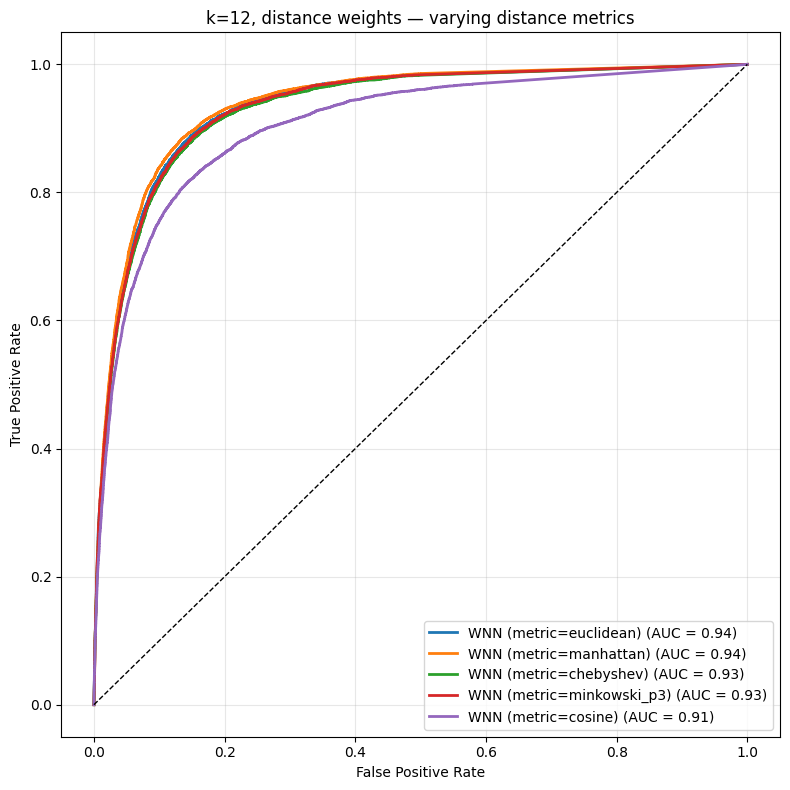

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier

def main():
    # 1) Load & preprocess
    df = pd.read_csv('soil_csv_pre-processed.csv')

    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    y = LabelBinarizer().fit_transform(df['Disease_Type'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=df['Disease_Type'], random_state=42
    )

    # 2) Define five distance-metric settings (k=12, weights=distance)
    metric_settings = [
        ('euclidean',        'euclidean'),
        ('manhattan',        'manhattan'),
        ('chebyshev',        'chebyshev'),
        ('minkowski_p3',     ('minkowski', 3)),
        ('cosine',           'cosine'),
    ]

    models = []
    for name, m in metric_settings:
        if isinstance(m, tuple):
            metric, p = m
            clf = KNeighborsClassifier(
                n_neighbors=12,
                weights='distance',
                metric=metric,
                p=p
            )
        else:
            clf = KNeighborsClassifier(
                n_neighbors=12,
                weights='distance',
                metric=m
            )
        models.append((f'WNN (metric={name})', clf))

    # 3) Train & plot micro-average ROC for each metric
    plt.figure(figsize=(8,8))
    for label, knn in models:
        ovr = OneVsRestClassifier(knn)
        ovr.fit(X_train, y_train)
        y_score = ovr.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

    # 4) Finalize plot
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('k=12, distance weights — varying distance metrics')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


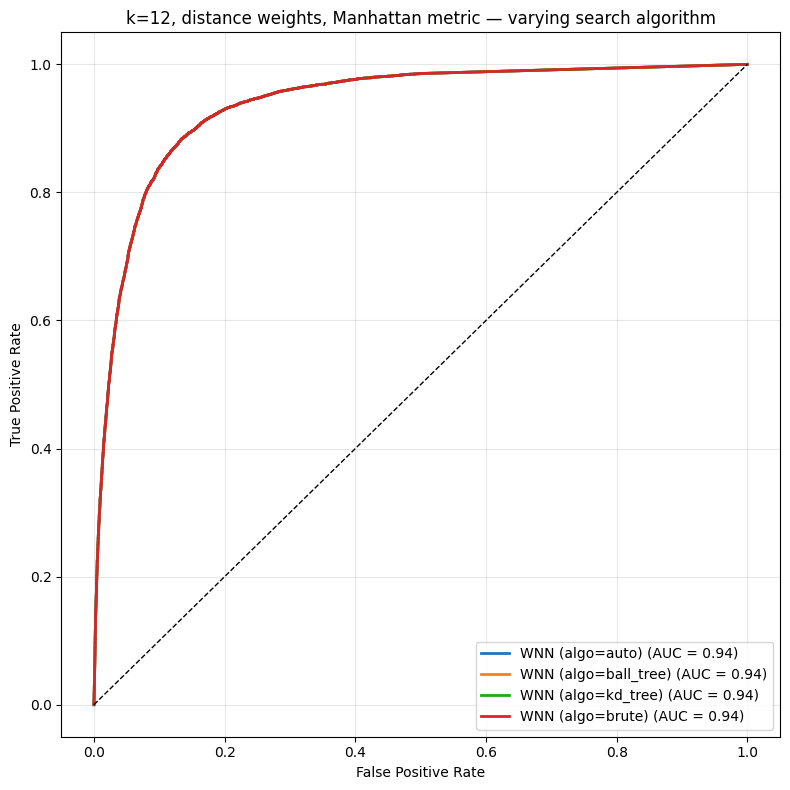

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier

def main():
    # 1) Load & preprocess
    df = pd.read_csv('soil_csv_pre-processed.csv')

    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    y = LabelBinarizer().fit_transform(df['Disease_Type'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=df['Disease_Type'], random_state=42
    )

    # 2) Compare search algorithms with k=12, weights=distance, metric=manhattan
    algo_settings = ['auto', 'ball_tree', 'kd_tree', 'brute']
    models = [
        (f'WNN (algo={algo})',
         KNeighborsClassifier(
            n_neighbors=12,
            weights='distance',
            metric='manhattan',
            algorithm=algo
         ))
        for algo in algo_settings
    ]

    # 3) Train & plot micro-average ROC for each algorithm
    plt.figure(figsize=(8,8))
    for label, knn in models:
        ovr = OneVsRestClassifier(knn)
        ovr.fit(X_train, y_train)
        y_score = ovr.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

    # 4) Finalize plot
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('k=12, distance weights, Manhattan metric — varying search algorithm')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


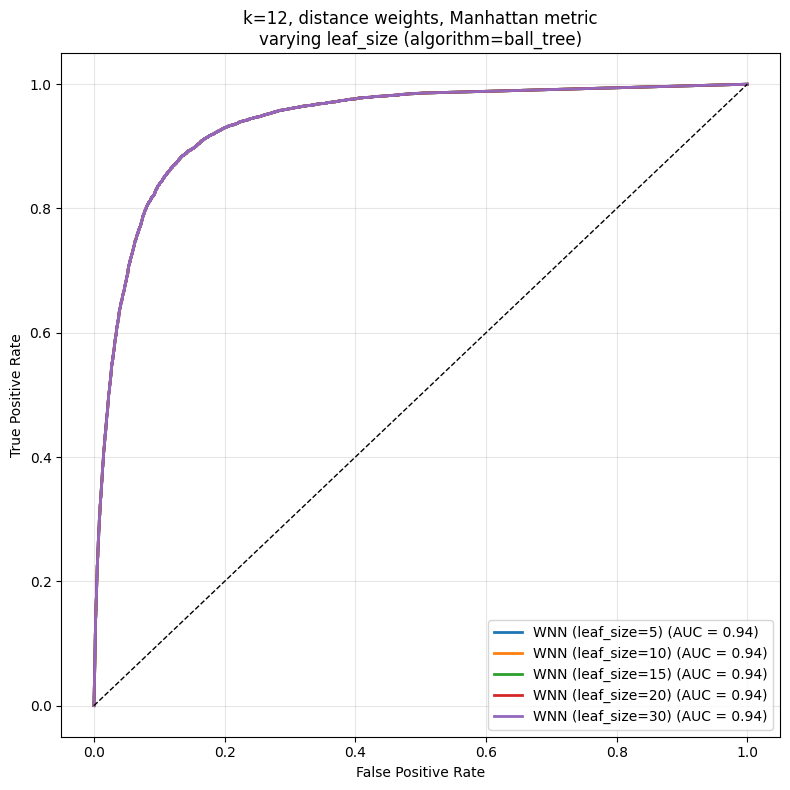

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier

def main():
    # 1) Load & preprocess
    df = pd.read_csv('soil_csv_pre-processed.csv')

    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    y = LabelBinarizer().fit_transform(df['Disease_Type'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=df['Disease_Type'], random_state=42
    )

    # 2) Vary leaf_size with algorithm=ball_tree (k=12, weights=distance, Manhattan)
    leaf_sizes = [5, 10, 15, 20, 30]
    models = [
        (f'WNN (leaf_size={leaf})',
         KNeighborsClassifier(
            n_neighbors=12,
            weights='distance',
            metric='manhattan',
            algorithm='ball_tree',
            leaf_size=leaf
         ))
        for leaf in leaf_sizes
    ]

    # 3) Train & plot micro-average ROC for each leaf_size
    plt.figure(figsize=(8,8))
    for label, knn in models:
        ovr = OneVsRestClassifier(knn)
        ovr.fit(X_train, y_train)
        y_score = ovr.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

    # 4) Finalize plot
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('k=12, distance weights, Manhattan metric\nvarying leaf_size (algorithm=ball_tree)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


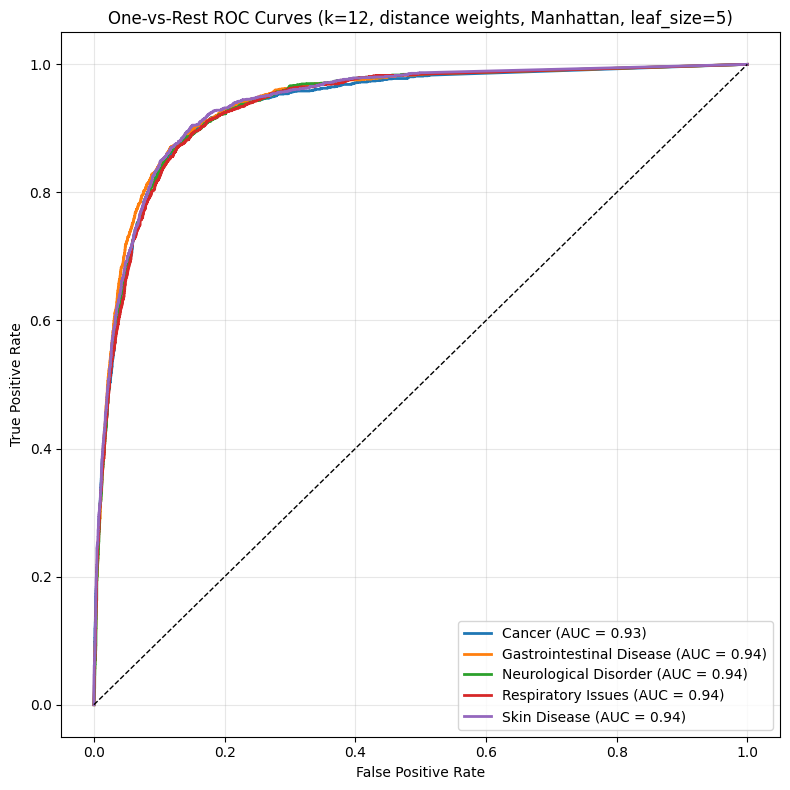

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier

def main():
    # 1) Load & preprocess
    df = pd.read_csv('soil_csv_pre-processed.csv')

    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    lb = LabelBinarizer()
    y = lb.fit_transform(df['Disease_Type'])
    class_names = lb.classes_

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=df['Disease_Type'], random_state=42
    )

    # 2) Single WNN model with leaf_size=5
    knn = KNeighborsClassifier(
        n_neighbors=12,
        weights='distance',
        metric='manhattan',
        algorithm='ball_tree',
        leaf_size=5
    )
    ovr = OneVsRestClassifier(knn)
    ovr.fit(X_train, y_train)
    y_score = ovr.predict_proba(X_test)  # shape = (n_samples, n_classes)

    # 3) Compute & plot one-vs-rest ROC for each class
    plt.figure(figsize=(8, 8))
    for i, class_label in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_label} (AUC = {roc_auc:.2f})')

    # 4) Chance line & finalize
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('One-vs-Rest ROC Curves (k=12, distance weights, Manhattan, leaf_size=5)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier

def main():
    # 1) Load & preprocess
    df = pd.read_csv('soil_csv_pre-processed.csv')
    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    y = LabelBinarizer().fit_transform(df['Disease_Type'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=df['Disease_Type'],
        random_state=42
    )

    # 2) Define base estimator and parameter distributions
    base_knn = KNeighborsClassifier()
    ovr = OneVsRestClassifier(base_knn)

    param_dist = {
        # number of neighbors
        'estimator__n_neighbors': randint(5, 31),
        # weighting scheme: either built-in or a custom small set
        'estimator__weights': ['uniform', 'distance'],
        # distance metric
        'estimator__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'cosine'],
        # p for Minkowski (only used if metric='minkowski')
        'estimator__p': randint(1, 5),
        # search algorithm
        'estimator__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        # leaf size (only for ball_tree / kd_tree)
        'estimator__leaf_size': randint(10, 51),
    }

    # 3) Set up RandomizedSearchCV
    rand_search = RandomizedSearchCV(
        estimator=ovr,
        param_distributions=param_dist,
        n_iter=50,                # number of configs to try
        scoring='roc_auc_ovr',    # micro-avg multiclass AUC
        cv=5,
        verbose=2,
        n_jobs=-1,
        random_state=42
    )

    # 4) Run the search
    rand_search.fit(X_train, y_train)

    # 5) Report best parameters and score
    print("Best ROC AUC (OVR micro):", rand_search.best_score_)
    print("Best hyper-parameters:")
    for key, val in rand_search.best_params_.items():
        print(f"  {key}: {val}")

    # 6) (Optional) Evaluate on held-out test set
    best_model = rand_search.best_estimator_
    y_pred_prob = best_model.predict_proba(X_test)
    test_auc = roc_auc_score(y_test, y_pred_prob, average='micro')
    print("Test ROC AUC (OVR micro):", test_auc)

if __name__ == '__main__':
    main()


Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Us

Best ROC AUC (OVR micro): 0.9302145177200798
Best hyper-parameters:
  estimator__algorithm: ball_tree
  estimator__leaf_size: 50
  estimator__metric: minkowski
  estimator__n_neighbors: 11
  estimator__p: 1
  estimator__weights: distance
Test ROC AUC (OVR micro): 0.9365250530308262


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score
)

def main():
    # 1) Load & preprocess
    df = pd.read_csv('soil_csv_pre-processed.csv')
    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    lb = LabelBinarizer()
    y = lb.fit_transform(df['Disease_Type'])
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=df['Disease_Type'],
        random_state=42
    )
    
    # 2) Build the WNN with your chosen hyper-parameters
    knn = KNeighborsClassifier(
        n_neighbors=11,
        weights='distance',
        metric='minkowski',
        p=1,
        algorithm='ball_tree',
        leaf_size=50
    )
    model = OneVsRestClassifier(knn)
    
    # 3) Fit & predict
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    y_proba   = model.predict_proba(X_test)
    
    # 4) Compute and print KPIs
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=lb.classes_,
        digits=4
    ))
    
    # ROC AUC (micro and macro)
    roc_micro = roc_auc_score(y_test, y_proba, average='micro')
    roc_macro = roc_auc_score(y_test, y_proba, average='macro')
    print(f"ROC AUC (micro): {roc_micro:.4f}")
    print(f"ROC AUC (macro): {roc_macro:.4f}")
    
    # Average Precision (micro)
    ap_micro = average_precision_score(y_test, y_proba, average='micro')
    print(f"Average Precision (micro): {ap_micro:.4f}")

if __name__ == '__main__':
    main()


Accuracy: 0.6874170720919947

Classification Report:
                          precision    recall  f1-score   support

                  Cancer     0.7682    0.6914    0.7277      1850
Gastrointestinal Disease     0.7958    0.6780    0.7322      1730
   Neurological Disorder     0.7839    0.6726    0.7240      1796
      Respiratory Issues     0.7621    0.6772    0.7172      1741
            Skin Disease     0.7790    0.7151    0.7457      1927

               micro avg     0.7775    0.6874    0.7297      9044
               macro avg     0.7778    0.6869    0.7294      9044
            weighted avg     0.7777    0.6874    0.7296      9044
             samples avg     0.6874    0.6874    0.6874      9044

ROC AUC (micro): 0.9365
ROC AUC (macro): 0.9365
Average Precision (micro): 0.7963


c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


: 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# Load data
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
y = df['Disease_Type']

# Binarize labels (optional if your model expects one-hot)
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# Train/test split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)

# Convert back to 1D class labels if needed
y_train = lb.inverse_transform(y_train_bin)


In [6]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression  # Simulating WNN with LR here

# Load dataset
df = pd.read_csv("soil_csv_pre-processed.csv")

# Separate features and labels
X = pd.get_dummies(df.drop(columns=["Disease_Type"]), drop_first=False)
y = df["Disease_Type"]

# Encode labels
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)
# You may still want y as categorical labels for multi-class classification
# In that case, use LabelEncoder instead:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train individual models
rf = KNeighborsClassifier(n_neighbors=5)
rf.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

wnn = LogisticRegression(max_iter=1000)
wnn.fit(X_train_scaled, y_train)

# Save models and transformers
joblib.dump(rf, "rf_soil_model.pkl")
joblib.dump(rf, "rf_soil_model.pkl")
joblib.dump(wnn, "wnn_soil_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(lb, "label_encoder.pkl")
joblib.dump(X.columns.tolist(), "X_encoded_columns.pkl")

print("✅ All models and encoders saved successfully.")


✅ All models and encoders saved successfully.


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score
)

def evaluate_wnn(model, X_test, y_test, label_binarizer):
    """Evaluate a trained WNN OneVsRest model on test data."""
    print("🔍 Evaluating model...")
    
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))

    print("\n📋 Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_binarizer.classes_,
        digits=4
    ))

    roc_micro = roc_auc_score(y_test, y_proba, average='micro')
    roc_macro = roc_auc_score(y_test, y_proba, average='macro')
    ap_micro  = average_precision_score(y_test, y_proba, average='micro')

    print(f"\n📈 ROC AUC (micro): {roc_micro:.4f}")
    print(f"📈 ROC AUC (macro): {roc_macro:.4f}")
    print(f"📊 Avg Precision (micro): {ap_micro:.4f}")

def main():
    # 1. Load & preprocess data
    df = pd.read_csv("soil_csv_pre-processed.csv")
    X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
    lb = LabelBinarizer()
    y = lb.fit_transform(df['Disease_Type'])

    # 2. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=df['Disease_Type'], random_state=42
    )

    # 3. Create and train the WNN model
    knn = KNeighborsClassifier(
        n_neighbors=11,
        weights='distance',
        metric='minkowski',
        p=1,
        algorithm='ball_tree',
        leaf_size=50
    )
    model = OneVsRestClassifier(knn)
    model.fit(X_train, y_train)

    # 4. Evaluate
    evaluate_wnn(model, X_test, y_test, lb)

if __name__ == "__main__":
    main()


🔍 Evaluating model...

✅ Accuracy: 0.6874170720919947

📋 Classification Report:
                          precision    recall  f1-score   support

                  Cancer     0.7682    0.6914    0.7277      1850
Gastrointestinal Disease     0.7958    0.6780    0.7322      1730
   Neurological Disorder     0.7839    0.6726    0.7240      1796
      Respiratory Issues     0.7621    0.6772    0.7172      1741
            Skin Disease     0.7790    0.7151    0.7457      1927

               micro avg     0.7775    0.6874    0.7297      9044
               macro avg     0.7778    0.6869    0.7294      9044
            weighted avg     0.7777    0.6874    0.7296      9044
             samples avg     0.6874    0.6874    0.6874      9044


📈 ROC AUC (micro): 0.9365
📈 ROC AUC (macro): 0.9365
📊 Avg Precision (micro): 0.7963


/Users/User/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Disease_Type'])
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']